In [127]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.svm import LinearSVC

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After successfully mounting, you can access your files. For example, if your `train.csv` file is in the root of your Google Drive, its path would be `/content/drive/MyDrive/train.csv`. If it's in a subfolder like `marketing-data`, the path would be `/content/drive/MyDrive/marketing-data/train.csv`.

Loading the Datasets

In [28]:
train_path = '/content/drive/MyDrive/marketing-dataset/train.csv'
train = pd.read_csv(train_path, sep=';', header=0)
train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [29]:
# creating headers to add to test
headers = train.columns[0:-1]
headers

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [30]:
test_path = '/content/drive/MyDrive/marketing-dataset/test.csv'
test = pd.read_csv(test_path, sep=';', header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,49,management,divorced,university.degree,no,no,no,cellular,jul,thu,144,5,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1
1,31,admin.,unknown,high.school,no,no,no,telephone,may,mon,182,8,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0
2,31,admin.,single,basic.9y,no,no,no,telephone,may,wed,80,1,999,1,failure,-1.8,92.893,-46.2,1.281,5099.1
3,60,admin.,married,high.school,no,yes,yes,cellular,apr,thu,482,2,999,0,nonexistent,-1.8,93.075,-47.1,1.365,5099.1
4,33,blue-collar,married,high.school,no,no,no,cellular,apr,mon,87,2,999,2,failure,-1.8,93.075,-47.1,1.405,5099.1


In [31]:
# adding headers to test df
test.columns = headers
test.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,49,management,divorced,university.degree,no,no,no,cellular,jul,thu,144,5,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1
1,31,admin.,unknown,high.school,no,no,no,telephone,may,mon,182,8,999,0,nonexistent,1.1,93.994,-36.4,4.858,5191.0
2,31,admin.,single,basic.9y,no,no,no,telephone,may,wed,80,1,999,1,failure,-1.8,92.893,-46.2,1.281,5099.1
3,60,admin.,married,high.school,no,yes,yes,cellular,apr,thu,482,2,999,0,nonexistent,-1.8,93.075,-47.1,1.365,5099.1
4,33,blue-collar,married,high.school,no,no,no,cellular,apr,mon,87,2,999,2,failure,-1.8,93.075,-47.1,1.405,5099.1


Data Cleaning

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2999 non-null   int64  
 1   job             2999 non-null   object 
 2   marital         2999 non-null   object 
 3   education       2999 non-null   object 
 4   default         2999 non-null   object 
 5   housing         2999 non-null   object 
 6   loan            2999 non-null   object 
 7   contact         2999 non-null   object 
 8   month           2999 non-null   object 
 9   day_of_week     2999 non-null   object 
 10  duration        2999 non-null   int64  
 11  campaign        2999 non-null   int64  
 12  pdays           2999 non-null   int64  
 13  previous        2999 non-null   int64  
 14  poutcome        2999 non-null   object 
 15  emp.var.rate    2999 non-null   float64
 16  cons.price.idx  2999 non-null   float64
 17  cons.conf.idx   2999 non-null   f

In [33]:
train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [34]:
train_obj = train.select_dtypes('object')
train_obj.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,nonexistent,no
1,services,single,high.school,no,no,no,telephone,may,fri,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,jun,wed,nonexistent,no
3,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,nonexistent,no
4,admin.,married,university.degree,no,yes,no,cellular,nov,mon,nonexistent,no


In [35]:
train_int = train.select_dtypes(['int64', 'float64'])
train_int.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8


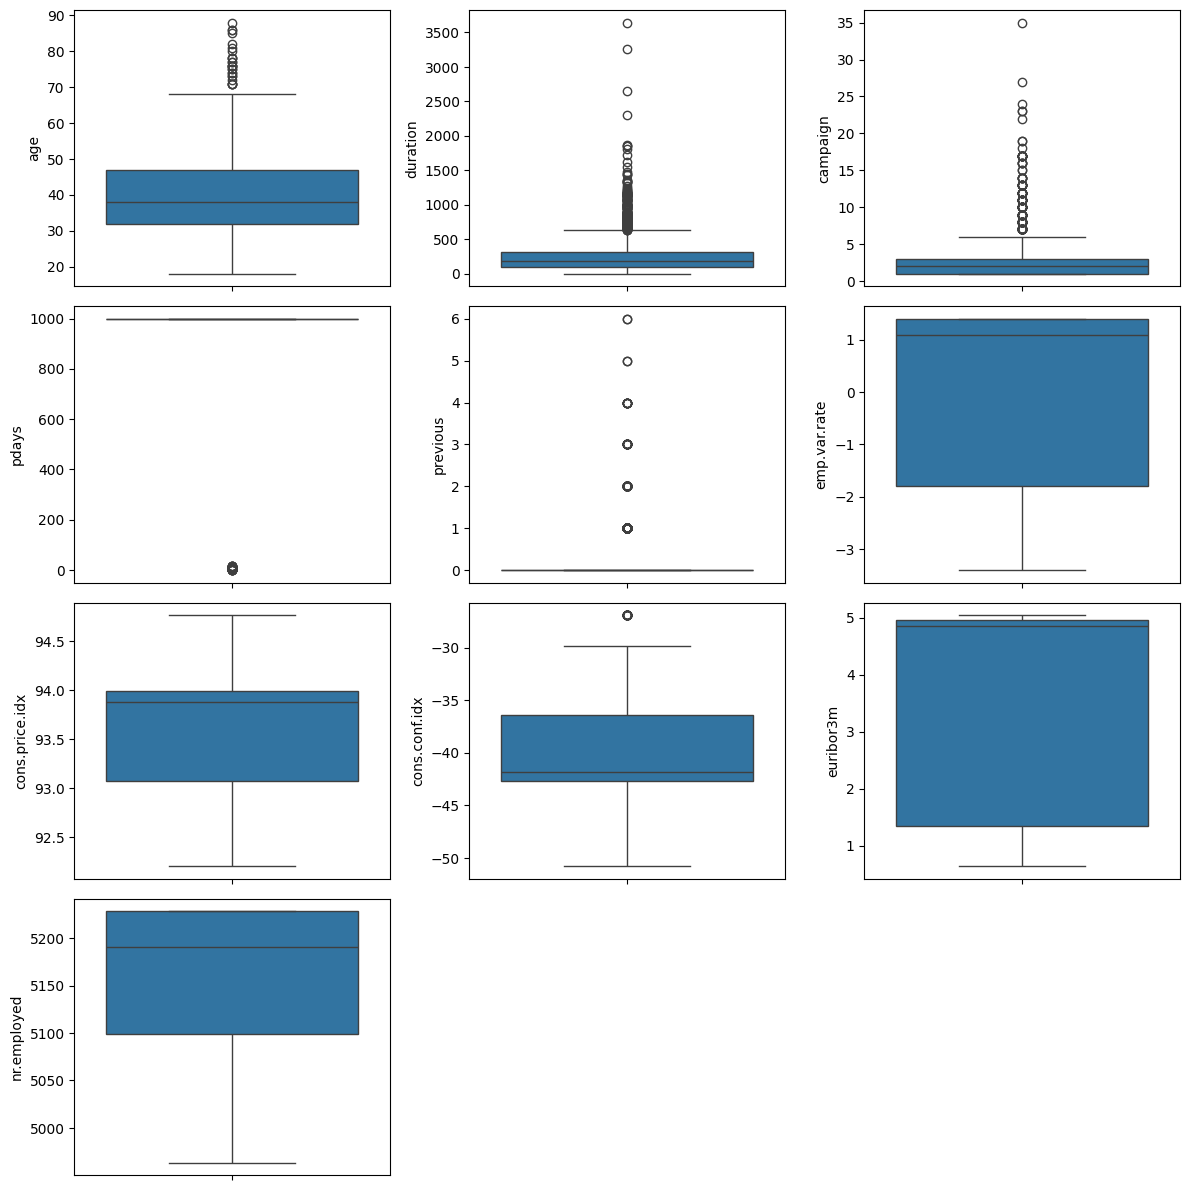

In [36]:
plt.figure(figsize=(12,12)) # Adjust figure size for better readability with more subplots

n = 1
for column in train_int.columns:
  plt.subplot(4,3,n) # Changed to 4 rows, 3 columns to accommodate 10 plots
  n += 1
  sns.boxplot(train_int[f"{column}"])


plt.tight_layout()
plt.show()

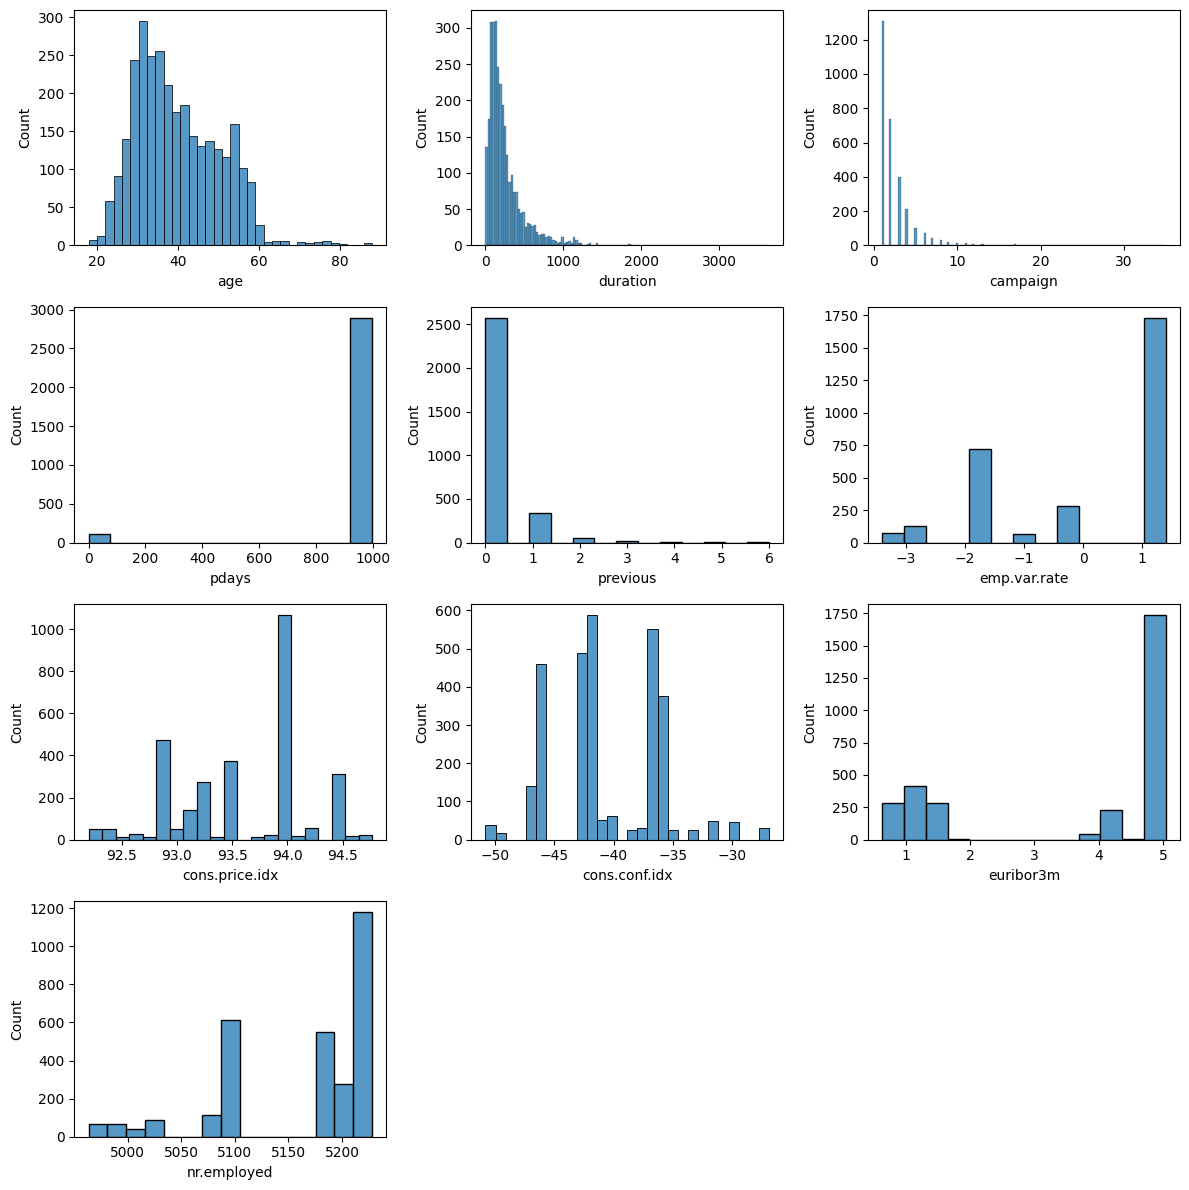

In [37]:
plt.figure(figsize=(12,12)) # Adjust figure size for better readability with more subplots

n = 1
for column in train_int.columns:
  plt.subplot(4,3,n) # Changed to 4 rows, 3 columns to accommodate 10 plots
  n += 1
  sns.histplot(train_int[f"{column}"])


plt.tight_layout()
plt.show()

In [38]:
# In pdays column, 999 represents someone who was never contacted, it's not numeric
# Breaking down this column into two for clearer interpretation

train['contacted'] = (train["pdays"] != 999).astype(int)
# NAN was not compatible with Logistic Regression Model
#train['pdays_numeric'] = train['pdays'].replace(999, np.nan)
train['pdays_numeric'] = train['pdays'].replace(999, -1)

train[train['contacted'] == 1].head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contacted,pdays_numeric
21,39,technician,divorced,high.school,no,no,no,cellular,mar,mon,...,2,success,-1.8,93.369,-34.8,0.639,5008.7,yes,1,12
53,24,technician,married,university.degree,no,yes,yes,cellular,sep,tue,...,1,success,-3.4,92.379,-29.8,0.770,5017.5,yes,1,3
62,52,admin.,married,unknown,no,yes,no,telephone,apr,wed,...,1,success,-1.8,93.749,-34.6,0.654,5008.7,yes,1,6
68,32,blue-collar,married,basic.9y,no,no,no,cellular,nov,mon,...,1,success,-0.1,93.200,-42.0,4.191,5195.8,yes,1,5
83,57,retired,married,university.degree,no,yes,no,cellular,apr,thu,...,1,success,-1.8,93.075,-47.1,1.365,5099.1,no,1,2


In [39]:
train[train['contacted'] == 0].head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contacted,pdays_numeric
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,0,-1
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no,0,-1
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no,0,-1
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no,0,-1
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no,0,-1


In [40]:
# Dropping pdays
train = train.drop(columns='pdays')
train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'contacted', 'pdays_numeric'],
      dtype='object')

<Axes: >

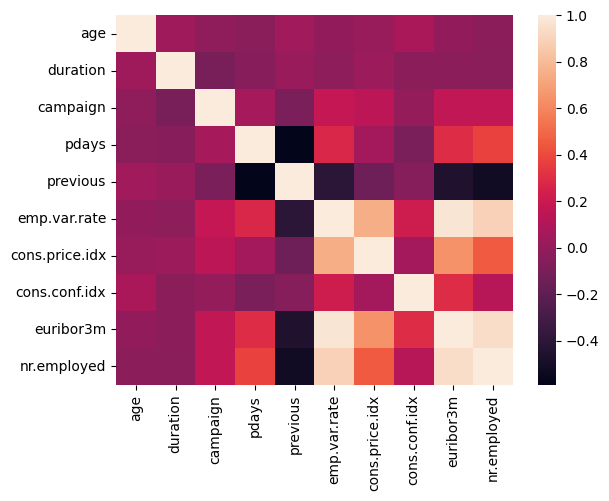

In [41]:
sns.heatmap(train_int.corr())

In [42]:
# Changing dtype for ML model
train['contacted'] = train['contacted'].astype('object')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2999 non-null   int64  
 1   job             2999 non-null   object 
 2   marital         2999 non-null   object 
 3   education       2999 non-null   object 
 4   default         2999 non-null   object 
 5   housing         2999 non-null   object 
 6   loan            2999 non-null   object 
 7   contact         2999 non-null   object 
 8   month           2999 non-null   object 
 9   day_of_week     2999 non-null   object 
 10  duration        2999 non-null   int64  
 11  campaign        2999 non-null   int64  
 12  previous        2999 non-null   int64  
 13  poutcome        2999 non-null   object 
 14  emp.var.rate    2999 non-null   float64
 15  cons.price.idx  2999 non-null   float64
 16  cons.conf.idx   2999 non-null   float64
 17  euribor3m       2999 non-null   f

Preparing data for Column Transformer

In [43]:
train_obj = train.select_dtypes('object')
train_obj = train_obj.drop(columns='y')
train_obj.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,contacted
0,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,nonexistent,0
1,services,single,high.school,no,no,no,telephone,may,fri,nonexistent,0
2,services,married,high.school,no,yes,no,telephone,jun,wed,nonexistent,0
3,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,nonexistent,0
4,admin.,married,university.degree,no,yes,no,cellular,nov,mon,nonexistent,0


In [44]:
train_int = train.select_dtypes(['int64', 'float64'])
train_int.head()

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_numeric
0,30,487,2,0,-1.8,92.893,-46.2,1.313,5099.1,-1
1,39,346,4,0,1.1,93.994,-36.4,4.855,5191.0,-1
2,25,227,1,0,1.4,94.465,-41.8,4.962,5228.1,-1
3,38,17,3,0,1.4,94.465,-41.8,4.959,5228.1,-1
4,47,58,1,0,-0.1,93.200,-42.0,4.191,5195.8,-1


In [45]:
# Creating list of column names that are of the object dtype
train_olist = train_obj.columns.tolist()
train_olist

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'contacted']

In [46]:
# Creating list of column names that are dtype float and integer
train_ilist = train_int.columns.tolist()
train_ilist

['age',
 'duration',
 'campaign',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'pdays_numeric']

In [47]:
# Creating evaluation function
def evaluate_log(pipeline):
  y_pred = pipeline.predict(X_test)
  y_prob = pipeline.predict_proba(X_test)[:, 1]
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
  print("\nClassification Report:\n", classification_report(y_test, y_pred))
  print("\nROC-AUC:", roc_auc_score(y_test, y_prob))
  print("\nMatthews Coefficient:", matthews_corrcoef(y_test, y_pred))

In [48]:
# Create X & y
X = train.drop("y", axis=1)
y = train["y"]

#Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
from sklearn.pipeline import Pipeline

preprocessor = make_column_transformer(
    (MinMaxScaler(), train_ilist), # Scale all values in this column between 0- 1
    (OneHotEncoder(handle_unknown="ignore"), train_olist)
)


# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [50]:
evaluate_log(pipeline)

Accuracy: 0.9066666666666666

Confusion Matrix:
 [[526  16]
 [ 40  18]]

Classification Report:
               precision    recall  f1-score   support

          no       0.93      0.97      0.95       542
         yes       0.53      0.31      0.39        58

    accuracy                           0.91       600
   macro avg       0.73      0.64      0.67       600
weighted avg       0.89      0.91      0.90       600


ROC-AUC: 0.9110255757729991

Matthews Coefficient: 0.35892276962627045


## Balanced Model

In [51]:
# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [52]:
evaluate_log(pipeline)

Accuracy: 0.8516666666666667

Confusion Matrix:
 [[460  82]
 [  7  51]]

Classification Report:
               precision    recall  f1-score   support

          no       0.99      0.85      0.91       542
         yes       0.38      0.88      0.53        58

    accuracy                           0.85       600
   macro avg       0.68      0.86      0.72       600
weighted avg       0.93      0.85      0.88       600


ROC-AUC: 0.9232090596768037

Matthews Coefficient: 0.5179311036730598


#10 Weight Model

In [53]:
# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight={'no':1, 'yes':10}))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [54]:
evaluate_log(pipeline)

Accuracy: 0.84

Confusion Matrix:
 [[450  92]
 [  4  54]]

Classification Report:
               precision    recall  f1-score   support

          no       0.99      0.83      0.90       542
         yes       0.37      0.93      0.53        58

    accuracy                           0.84       600
   macro avg       0.68      0.88      0.72       600
weighted avg       0.93      0.84      0.87       600


ROC-AUC: 0.9249586461381856

Matthews Coefficient: 0.5242772343636269


# Model with SFS feature selection

In [124]:
sfs = SequentialFeatureSelector(LogisticRegression(class_weight={'no':1, 'yes':10}), n_features_to_select=38, direction='forward')

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features', sfs),
    ('classifier', LogisticRegression(class_weight={'no':1, 'yes':10}))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [125]:
# Get feature names AFTER transformation
feature_names = preprocessor.get_feature_names_out()

# Get mask of selected features
selected_mask = sfs.get_support()

# Print selected feature names
print("Selected features:", feature_names[selected_mask])

Selected features: ['minmaxscaler__duration' 'minmaxscaler__previous'
 'minmaxscaler__cons.conf.idx' 'minmaxscaler__pdays_numeric'
 'onehotencoder__job_admin.' 'onehotencoder__job_entrepreneur'
 'onehotencoder__job_housemaid' 'onehotencoder__job_management'
 'onehotencoder__job_retired' 'onehotencoder__job_self-employed'
 'onehotencoder__job_services' 'onehotencoder__job_student'
 'onehotencoder__job_unknown' 'onehotencoder__marital_divorced'
 'onehotencoder__marital_married' 'onehotencoder__marital_single'
 'onehotencoder__marital_unknown' 'onehotencoder__education_basic.4y'
 'onehotencoder__education_basic.6y'
 'onehotencoder__education_high.school'
 'onehotencoder__education_professional.course'
 'onehotencoder__education_unknown' 'onehotencoder__housing_unknown'
 'onehotencoder__loan_unknown' 'onehotencoder__month_aug'
 'onehotencoder__month_dec' 'onehotencoder__month_jun'
 'onehotencoder__month_mar' 'onehotencoder__month_nov'
 'onehotencoder__month_oct' 'onehotencoder__day_of_week

In [126]:
evaluate_log(pipeline)

Accuracy: 0.8266666666666667

Confusion Matrix:
 [[449  93]
 [ 11  47]]

Classification Report:
               precision    recall  f1-score   support

          no       0.98      0.83      0.90       542
         yes       0.34      0.81      0.47        58

    accuracy                           0.83       600
   macro avg       0.66      0.82      0.69       600
weighted avg       0.91      0.83      0.86       600


ROC-AUC: 0.8974742333630232

Matthews Coefficient: 0.4462797023418573


# Model with Kmeans Feature Selection

In [69]:
selector = SelectKBest(score_func=f_classif, k=20)

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features', selector),
    ('classifier', LogisticRegression(class_weight={'no':1, 'yes':10}))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [70]:
feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[selector.get_support()]

print(selected_features)

['minmaxscaler__age' 'minmaxscaler__duration' 'minmaxscaler__campaign'
 'minmaxscaler__previous' 'minmaxscaler__emp.var.rate'
 'minmaxscaler__euribor3m' 'minmaxscaler__nr.employed'
 'minmaxscaler__pdays_numeric' 'onehotencoder__job_retired'
 'onehotencoder__default_no' 'onehotencoder__contact_cellular'
 'onehotencoder__contact_telephone' 'onehotencoder__month_mar'
 'onehotencoder__month_may' 'onehotencoder__month_oct'
 'onehotencoder__month_sep' 'onehotencoder__poutcome_nonexistent'
 'onehotencoder__poutcome_success' 'onehotencoder__contacted_0'
 'onehotencoder__contacted_1']


In [71]:
evaluate_log(pipeline)

Accuracy: 0.84

Confusion Matrix:
 [[450  92]
 [  4  54]]

Classification Report:
               precision    recall  f1-score   support

          no       0.99      0.83      0.90       542
         yes       0.37      0.93      0.53        58

    accuracy                           0.84       600
   macro avg       0.68      0.88      0.72       600
weighted avg       0.93      0.84      0.87       600


ROC-AUC: 0.9317661280061076

Matthews Coefficient: 0.5242772343636269


# Finding k for optimal Matthew's Coefficient value

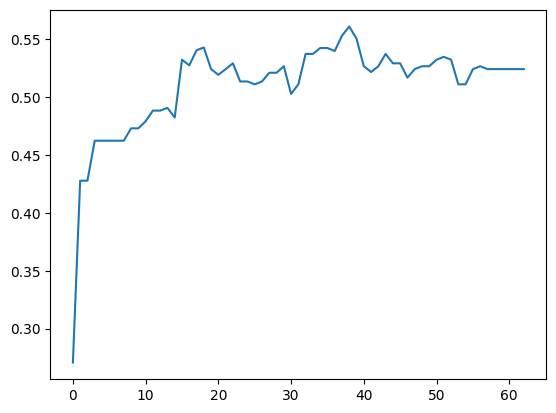

In [84]:
matthews_list = []
n_features = len(preprocessor.get_feature_names_out())
for i in range(1, n_features + 1):
  selector = SelectKBest(score_func=f_classif, k=i)

  # Define the pipeline
  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('features', selector),
      ('classifier', LogisticRegression(class_weight={'no':1, 'yes':10}))
  ])

  # Train pipeline
  pipeline.fit(X_train, y_train)

  # Test pipeline
  y_pred = pipeline.predict(X_test)
  y_prob = pipeline.predict_proba(X_test)[:, 1]
  matthews_list.append(matthews_corrcoef(y_test, y_pred))

plt.plot(matthews_list)
plt.show()

In [96]:
max_value = matthews_list.index(max(matthews_list))

37

# Model with optimal Kmeans feature selection

In [101]:
selector = SelectKBest(score_func=f_classif, k=max_value + 1)

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features', selector),
    ('classifier', LogisticRegression(class_weight={'no':1, 'yes':10}))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [102]:
feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[selector.get_support()]

print(selected_features)

['minmaxscaler__age' 'minmaxscaler__duration' 'minmaxscaler__campaign'
 'minmaxscaler__previous' 'minmaxscaler__emp.var.rate'
 'minmaxscaler__cons.price.idx' 'minmaxscaler__cons.conf.idx'
 'minmaxscaler__euribor3m' 'minmaxscaler__nr.employed'
 'minmaxscaler__pdays_numeric' 'onehotencoder__job_admin.'
 'onehotencoder__job_blue-collar' 'onehotencoder__job_retired'
 'onehotencoder__job_self-employed' 'onehotencoder__job_services'
 'onehotencoder__job_student' 'onehotencoder__job_unemployed'
 'onehotencoder__marital_single' 'onehotencoder__education_basic.9y'
 'onehotencoder__education_university.degree' 'onehotencoder__default_no'
 'onehotencoder__default_unknown' 'onehotencoder__housing_unknown'
 'onehotencoder__loan_unknown' 'onehotencoder__contact_cellular'
 'onehotencoder__contact_telephone' 'onehotencoder__month_apr'
 'onehotencoder__month_aug' 'onehotencoder__month_dec'
 'onehotencoder__month_jun' 'onehotencoder__month_mar'
 'onehotencoder__month_may' 'onehotencoder__month_oct'
 'on

In [103]:
evaluate_log(pipeline)

Accuracy: 0.8483333333333334

Confusion Matrix:
 [[452  90]
 [  1  57]]

Classification Report:
               precision    recall  f1-score   support

          no       1.00      0.83      0.91       542
         yes       0.39      0.98      0.56        58

    accuracy                           0.85       600
   macro avg       0.69      0.91      0.73       600
weighted avg       0.94      0.85      0.87       600


ROC-AUC: 0.9361241888280951

Matthews Coefficient: 0.5611411636634325


# SVM Model

In [115]:
# Creating evaluation function
def evaluate_svm(pipeline):
  y_pred = pipeline.predict(X_test)
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
  print("\nClassification Report:\n", classification_report(y_test, y_pred))
  print("\nMatthews Coefficient:", matthews_corrcoef(y_test, y_pred))

In [116]:
from sklearn.svm import LinearSVC

# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features', selector),
    ('classifier', LinearSVC())
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)

In [117]:
evaluate_svm(pipeline)

Accuracy: 0.9116666666666666

Confusion Matrix:
 [[524  18]
 [ 35  23]]

Classification Report:
               precision    recall  f1-score   support

          no       0.94      0.97      0.95       542
         yes       0.56      0.40      0.46        58

    accuracy                           0.91       600
   macro avg       0.75      0.68      0.71       600
weighted avg       0.90      0.91      0.90       600


Matthews Coefficient: 0.4255304899845727


# SVM Model with weights

In [118]:
# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features', selector),
    ('classifier', LinearSVC(class_weight={'no':1, 'yes':10}))
])

# Train pipeline
pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = pipeline.predict(X_test)

In [119]:
evaluate_svm(pipeline)

Accuracy: 0.8416666666666667

Confusion Matrix:
 [[450  92]
 [  3  55]]

Classification Report:
               precision    recall  f1-score   support

          no       0.99      0.83      0.90       542
         yes       0.37      0.95      0.54        58

    accuracy                           0.84       600
   macro avg       0.68      0.89      0.72       600
weighted avg       0.93      0.84      0.87       600


Matthews Coefficient: 0.5349134859974624


# Saving optimal model for deployment

In [104]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('features', SelectKBest(f_classif, k=38)),  # or remove if not used
    ('classifier', LogisticRegression(class_weight={'no':1, 'yes':10}, max_iter=1000))
])

In [105]:
final_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('minmaxscaler',
                                                  MinMaxScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'previous',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'pdays_numeric']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome',
                                                   'contacted'])])),
                ('features', SelectKBest(k=38)),
                ('classifier',
                 LogisticRegression(class_weight={'no': 1, 'yes': 10},
                                    max_iter=1000))])

In [106]:
import joblib

joblib.dump(final_pipeline, "/content/drive/MyDrive/final_model.pkl")

['/content/drive/MyDrive/final_model.pkl']